# Etapa 5 — Ajuste de Threshold via Validação

Na Etapa 4, o XGBoost alcançou ROC-AUC 0.670 mas accuracy de apenas 30.8%
porque o threshold padrão (0.5) gerava previsões degeneradas.

Este notebook busca o threshold ótimo no conjunto de validação e avalia o impacto
em todos os modelos treinados com features FinBERT.

## 1. Carregar Dataset e Treinar Modelos

In [1]:
import sys
sys.path.insert(0, '../3.model_traning')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Load dataset (same as Etapa 4)
X_full = pd.read_csv('../2.stocks/dataset_full.csv', index_col=0, parse_dates=True)
X_full.index = pd.to_datetime(X_full.index, utc=True).tz_localize(None)

price_cols = [c for c in X_full.columns if not c.startswith('emb_')]
X_prices = X_full[price_cols].copy()

sentiment = pd.read_csv('../4.finbert-br/itub4_daily_sentiment.csv', index_col=0, parse_dates=True)
X_combined = X_prices.join(sentiment, how='left')
sent_cols = sentiment.columns.tolist()
X_combined[sent_cols] = X_combined[sent_cols].ffill()
X_combined = X_combined.dropna()

print(f'Dataset: {X_combined.shape}')

Dataset: (1227, 16)


In [2]:
from lstm_classifier import build_dataset, train, evaluate
from xgboost_baseline import build_flat_dataset, train_xgboost
from transformer_classifier import train_transformer, evaluate_transformer

# Sequential models
X_seq, y, dates, features, scaler = build_dataset(X_combined, horizon=21, pca_components=32, window=30)

# Train all 4 models
print('\n=== BiLSTM Original ===')
model_orig, hist_orig, test_idx_orig, device = train(X_seq, y, dates, hidden_size=128, n_layers=2, dropout=0.3, epochs=50, patience=10)

print('\n=== BiLSTM Reduzido ===')
model_red, hist_red, test_idx_red, _ = train(X_seq, y, dates, hidden_size=64, n_layers=1, dropout=0.2, epochs=50, patience=10)

print('\n=== XGBoost ===')
X_flat, y_flat, dates_flat, features_flat = build_flat_dataset(X_combined, horizon=21, pca_components=32)
xgb_model, X_test_xgb, y_test_xgb, test_dates_xgb = train_xgboost(X_flat, y_flat, dates_flat)

print('\n=== Transformer ===')
tf_model, hist_tf, test_idx_tf, _ = train_transformer(X_seq, y, dates, d_model=64, nhead=4, n_layers=2, dropout=0.3, epochs=50, patience=10)

09:33:51 [INFO] Shape de entrada: (1227, 16)
09:33:51 [INFO] Distribuição do target: {1: 712, 0: 494}  (balance: 59.0% sobe)
09:33:51 [INFO] Features finais: 16
09:33:51 [INFO] Sequências geradas: (1176, 30, 16)  →  y: (1176,)
09:33:51 [INFO] Split — treino: 823 | val: 176 | teste: 177
09:33:51 [INFO] Treino: 2021-06-10 → 2024-09-23
09:33:51 [INFO] Val:    2024-09-24 → 2025-06-11
09:33:51 [INFO] Teste:  2025-06-12 → 2026-02-25



=== BiLSTM Original ===


09:33:53 [INFO] Device: cuda
09:33:55 [INFO] Epoch   1/50 | loss 0.6930 | val_loss 0.6982 | val_acc 38.1% | lr 1.00e-03
09:33:55 [INFO] Epoch   2/50 | loss 0.6785 | val_loss 0.7086 | val_acc 33.0% | lr 1.00e-03
09:33:55 [INFO] Epoch   3/50 | loss 0.6643 | val_loss 0.7329 | val_acc 31.8% | lr 1.00e-03
09:33:55 [INFO] Epoch   4/50 | loss 0.6422 | val_loss 0.8193 | val_acc 27.3% | lr 1.00e-03
09:33:55 [INFO] Epoch   5/50 | loss 0.6087 | val_loss 1.1157 | val_acc 18.8% | lr 1.00e-03
09:33:56 [INFO] Epoch   6/50 | loss 0.5861 | val_loss 1.1914 | val_acc 21.6% | lr 1.00e-03
09:33:56 [INFO] Epoch   7/50 | loss 0.5893 | val_loss 0.9872 | val_acc 43.8% | lr 5.00e-04
09:33:56 [INFO] Epoch   8/50 | loss 0.5388 | val_loss 1.3070 | val_acc 29.0% | lr 5.00e-04
09:33:56 [INFO] Epoch   9/50 | loss 0.5585 | val_loss 1.2841 | val_acc 49.4% | lr 5.00e-04
09:33:56 [INFO] Epoch  10/50 | loss 0.6373 | val_loss 1.1034 | val_acc 52.3% | lr 5.00e-04
09:33:56 [INFO] Epoch  11/50 | loss 0.5451 | val_loss 1.4936 


=== BiLSTM Reduzido ===


09:33:57 [INFO] Epoch   2/50 | loss 0.6846 | val_loss 0.7034 | val_acc 37.5% | lr 1.00e-03
09:33:57 [INFO] Epoch   3/50 | loss 0.6726 | val_loss 0.7135 | val_acc 35.8% | lr 1.00e-03
09:33:57 [INFO] Epoch   4/50 | loss 0.6539 | val_loss 0.7278 | val_acc 30.1% | lr 1.00e-03
09:33:57 [INFO] Epoch   5/50 | loss 0.6315 | val_loss 0.7499 | val_acc 31.8% | lr 1.00e-03
09:33:57 [INFO] Epoch   6/50 | loss 0.6102 | val_loss 0.8257 | val_acc 24.4% | lr 1.00e-03
09:33:57 [INFO] Epoch   7/50 | loss 0.5717 | val_loss 1.0735 | val_acc 21.0% | lr 5.00e-04
09:33:57 [INFO] Epoch   8/50 | loss 0.5442 | val_loss 1.2809 | val_acc 17.0% | lr 5.00e-04
09:33:58 [INFO] Epoch   9/50 | loss 0.5295 | val_loss 1.2766 | val_acc 29.5% | lr 5.00e-04
09:33:58 [INFO] Epoch  10/50 | loss 0.5254 | val_loss 1.4605 | val_acc 18.8% | lr 5.00e-04
09:33:58 [INFO] Epoch  11/50 | loss 0.5304 | val_loss 1.5420 | val_acc 20.5% | lr 5.00e-04
09:33:58 [INFO] Early stopping na epoch 11
09:33:58 [INFO] Shape de entrada: (1227, 16)
09


=== XGBoost ===

=== Transformer ===


09:33:58 [INFO] Epoch   1/50 | loss 0.7296 | val_loss 0.7050 | val_acc 40.3% | lr 1.00e-03
09:33:58 [INFO] Epoch   2/50 | loss 0.7054 | val_loss 0.6884 | val_acc 46.6% | lr 1.00e-03
09:33:59 [INFO] Epoch   3/50 | loss 0.6857 | val_loss 0.7057 | val_acc 41.5% | lr 1.00e-03
09:33:59 [INFO] Epoch   4/50 | loss 0.6852 | val_loss 0.7528 | val_acc 34.1% | lr 1.00e-03
09:33:59 [INFO] Epoch   5/50 | loss 0.6740 | val_loss 0.8460 | val_acc 26.1% | lr 1.00e-03
09:33:59 [INFO] Epoch   6/50 | loss 0.6539 | val_loss 0.9859 | val_acc 26.7% | lr 1.00e-03
09:33:59 [INFO] Epoch   7/50 | loss 0.6346 | val_loss 1.0252 | val_acc 19.9% | lr 1.00e-03
09:34:00 [INFO] Epoch   8/50 | loss 0.6132 | val_loss 1.2098 | val_acc 16.5% | lr 5.00e-04
09:34:00 [INFO] Epoch   9/50 | loss 0.6058 | val_loss 1.2235 | val_acc 14.8% | lr 5.00e-04
09:34:00 [INFO] Epoch  10/50 | loss 0.5712 | val_loss 1.0668 | val_acc 31.8% | lr 5.00e-04
09:34:00 [INFO] Epoch  11/50 | loss 0.5847 | val_loss 1.3538 | val_acc 22.7% | lr 5.00e-04

## 2. Extrair Probabilidades no Conjunto de Validação e Teste

In [9]:
import torch

# Split indices (same 70/15/15 used in training)
n = len(X_seq)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
val_idx = slice(n_train, n_train + n_val)
test_idx = slice(n_train + n_val, n)

def get_probs_torch(model, X_seq, idx):
    model.eval()
    X = torch.tensor(X_seq[idx], dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(X).cpu().numpy()

# Validation probs (for threshold search)
val_probs = {
    'BiLSTM Original': get_probs_torch(model_orig, X_seq, val_idx),
    'BiLSTM Reduzido': get_probs_torch(model_red, X_seq, val_idx),
    'Transformer': get_probs_torch(tf_model, X_seq, val_idx),
}
y_val = y[val_idx]

# XGBoost val probs (different split sizes due to no windowing)
n_xgb = len(X_flat)
n_train_xgb = int(n_xgb * 0.7)
n_val_xgb = int(n_xgb * 0.15)
X_val_xgb = X_flat[n_train_xgb:n_train_xgb + n_val_xgb]
y_val_xgb = y_flat[n_train_xgb:n_train_xgb + n_val_xgb]
val_probs['XGBoost'] = xgb_model.predict_proba(X_val_xgb)[:, 1]

# Test probs
test_probs = {
    'BiLSTM Original': get_probs_torch(model_orig, X_seq, test_idx),
    'BiLSTM Reduzido': get_probs_torch(model_red, X_seq, test_idx),
    'Transformer': get_probs_torch(tf_model, X_seq, test_idx),
    'XGBoost': xgb_model.predict_proba(X_test_xgb)[:, 1],
}
y_test_seq = y[test_idx]

print(f'Val samples (seq): {len(y_val)}, Val samples (xgb): {len(y_val_xgb)}')
print(f'Test samples (seq): {len(y_test_seq)}, Test samples (xgb): {len(y_test_xgb)}')

Val samples (seq): 176, Val samples (xgb): 180
Test samples (seq): 177, Test samples (xgb): 182


## 3. Busca de Threshold Ótimo na Validação

Para cada modelo, testamos thresholds de 0.1 a 0.9 e selecionamos o que maximiza o **F1-score**
no conjunto de validação. Usamos F1 ao invés de accuracy porque o dataset é desbalanceado (59/41).

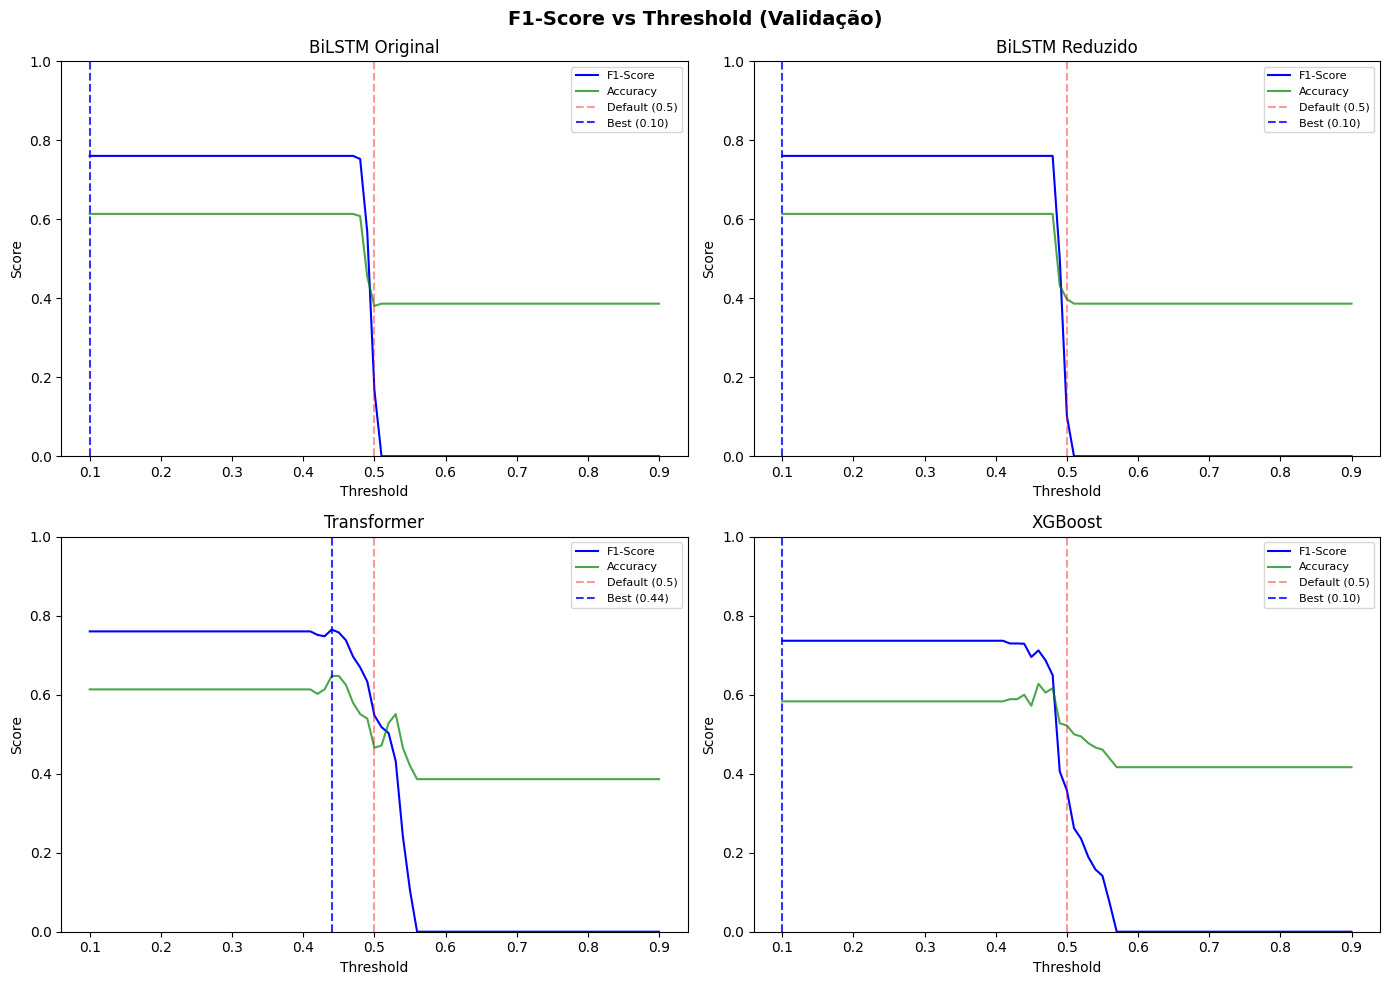


Thresholds ótimos (validação):
  BiLSTM Original: 0.10
  BiLSTM Reduzido: 0.10
  Transformer: 0.44
  XGBoost: 0.10


In [10]:
thresholds = np.arange(0.10, 0.91, 0.01)

best_thresholds = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('F1-Score vs Threshold (Validação)', fontsize=14, fontweight='bold')

for ax, (name, probs) in zip(axes.flat, val_probs.items()):
    y_v = y_val_xgb if name == 'XGBoost' else y_val
    
    f1s = [f1_score(y_v, (probs > t).astype(int), zero_division=0) for t in thresholds]
    accs = [accuracy_score(y_v, (probs > t).astype(int)) for t in thresholds]
    
    best_t = thresholds[np.argmax(f1s)]
    best_thresholds[name] = best_t
    
    ax.plot(thresholds, f1s, label='F1-Score', color='blue')
    ax.plot(thresholds, accs, label='Accuracy', color='green', alpha=0.7)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Default (0.5)')
    ax.axvline(best_t, color='blue', linestyle='--', alpha=0.8, label=f'Best ({best_t:.2f})')
    ax.set_title(f'{name}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('threshold_search.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThresholds ótimos (validação):')
for name, t in best_thresholds.items():
    print(f'  {name}: {t:.2f}')

## 4. Avaliação no Teste: Default (0.5) vs Threshold Otimizado

In [12]:
rows = []

for name, probs in test_probs.items():
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    
    # Default threshold 0.5
    preds_default = (probs > 0.5).astype(int)
    # Optimized threshold
    preds_opt = (probs > t_opt).astype(int)
    
    auc = roc_auc_score(y_t, probs)
    
    rows.append({
        'Modelo': name,
        'Threshold': 0.5,
        'ROC-AUC': auc,
        'Accuracy': accuracy_score(y_t, preds_default),
        'F1 (Sobe)': f1_score(y_t, preds_default, zero_division=0),
        'Precision': precision_score(y_t, preds_default, zero_division=0),
        'Recall': recall_score(y_t, preds_default, zero_division=0),
    })
    rows.append({
        'Modelo': name,
        'Threshold': t_opt,
        'ROC-AUC': auc,
        'Accuracy': accuracy_score(y_t, preds_opt),
        'F1 (Sobe)': f1_score(y_t, preds_opt, zero_division=0),
        'Precision': precision_score(y_t, preds_opt, zero_division=0),
        'Recall': recall_score(y_t, preds_opt, zero_division=0),
    })

df_compare = pd.DataFrame(rows)
display(df_compare.style.format({
    'Threshold': '{:.2f}',
    'ROC-AUC': '{:.4f}',
    'Accuracy': '{:.1%}',
    'F1 (Sobe)': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
}).highlight_max(axis=0, subset=['Accuracy', 'F1 (Sobe)'], color='lightgreen'))

,Modelo,Threshold,ROC-AUC,Accuracy,F1 (Sobe),Precision,Recall
0,BiLSTM Original,0.50,0.4649,30.5%,0.0000,0.0000,0.0000
1,BiLSTM Original,0.10,0.4649,69.5%,0.8200,0.6949,1.0000
2,BiLSTM Reduzido,0.50,0.3424,30.5%,0.0000,0.0000,0.0000
3,BiLSTM Reduzido,0.10,0.3424,69.5%,0.8200,0.6949,1.0000
4,Transformer,0.50,0.6357,30.5%,0.0000,0.0000,0.0000
5,Transformer,0.44,0.6357,41.2%,0.2676,1.0000,0.1545
6,XGBoost,0.50,0.6698,30.8%,0.0000,0.0000,0.0000
7,XGBoost,0.10,0.6698,69.2%,0.8182,0.6923,1.0000


## 5. Matrizes de Confusão — Threshold Otimizado

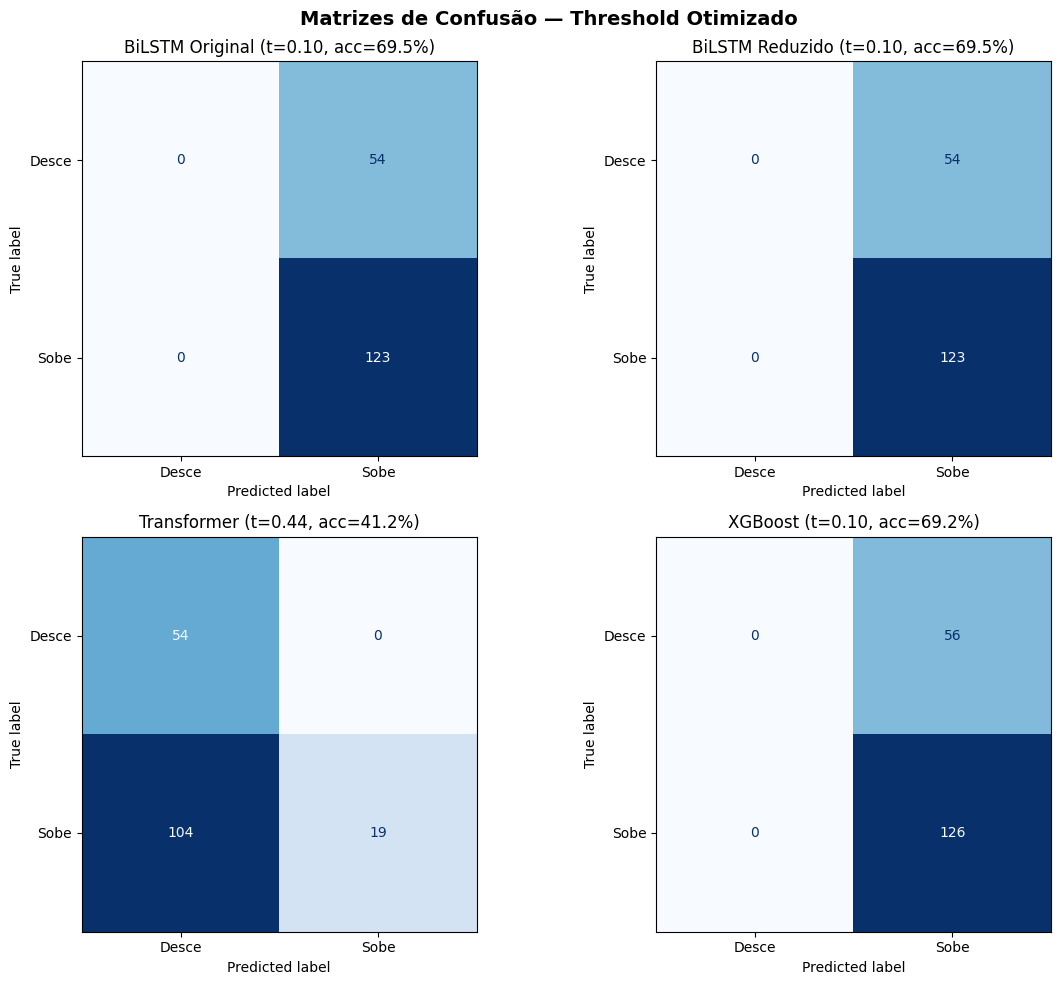

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrizes de Confusão — Threshold Otimizado', fontsize=14, fontweight='bold')

for ax, (name, probs) in zip(axes.flat, test_probs.items()):
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    preds = (probs > t_opt).astype(int)
    
    cm = confusion_matrix(y_t, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Desce', 'Sobe'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_t, preds)
    ax.set_title(f'{name} (t={t_opt:.2f}, acc={acc:.1%})')

plt.tight_layout()
plt.savefig('confusion_matrices_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Curvas ROC com Threshold Ótimo Marcado

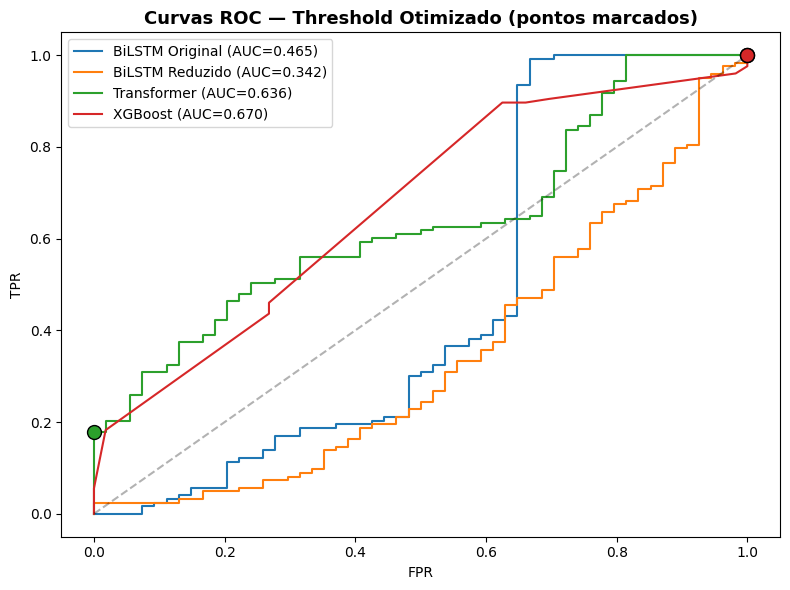

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (name, probs), color in zip(test_probs.items(), colors):
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    
    fpr, tpr, curve_thresholds = roc_curve(y_t, probs)
    auc = roc_auc_score(y_t, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
    
    # Mark optimal threshold point
    idx_opt = np.argmin(np.abs(curve_thresholds - t_opt))
    ax.scatter(fpr[idx_opt], tpr[idx_opt], color=color, s=100, zorder=5, edgecolors='black')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('Curvas ROC — Threshold Otimizado (pontos marcados)', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.tight_layout()
plt.savefig('roc_threshold_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumo e Conclusões

In [16]:
# Final summary: best result per model with optimized threshold
print('RESUMO FINAL — Threshold Otimizado via Validação')
print('=' * 70)

for name, probs in test_probs.items():
    y_t = y_test_xgb if name == 'XGBoost' else y_test_seq
    t_opt = best_thresholds[name]
    preds = (probs > t_opt).astype(int)
    
    auc = roc_auc_score(y_t, probs)
    acc = accuracy_score(y_t, preds)
    f1 = f1_score(y_t, preds, zero_division=0)
    
    # Compare with default
    preds_def = (probs > 0.5).astype(int)
    acc_def = accuracy_score(y_t, preds_def)
    f1_def = f1_score(y_t, preds_def, zero_division=0)
    
    delta_acc = acc - acc_def
    delta_f1 = f1 - f1_def
    
    print(f'\n{name}')
    print(f'  Threshold: 0.50 -> {t_opt:.2f}')
    print(f'  ROC-AUC:   {auc:.4f}')
    print(f'  Accuracy:  {acc_def:.1%} -> {acc:.1%} ({delta_acc:+.1%})')
    print(f'  F1 (Sobe): {f1_def:.4f} -> {f1:.4f} ({delta_f1:+.4f})')

RESUMO FINAL — Threshold Otimizado via Validação

BiLSTM Original
  Threshold: 0.50 -> 0.10
  ROC-AUC:   0.4649
  Accuracy:  30.5% -> 69.5% (+39.0%)
  F1 (Sobe): 0.0000 -> 0.8200 (+0.8200)

BiLSTM Reduzido
  Threshold: 0.50 -> 0.10
  ROC-AUC:   0.3424
  Accuracy:  30.5% -> 69.5% (+39.0%)
  F1 (Sobe): 0.0000 -> 0.8200 (+0.8200)

Transformer
  Threshold: 0.50 -> 0.44
  ROC-AUC:   0.6357
  Accuracy:  30.5% -> 41.2% (+10.7%)
  F1 (Sobe): 0.0000 -> 0.2676 (+0.2676)

XGBoost
  Threshold: 0.50 -> 0.10
  ROC-AUC:   0.6698
  Accuracy:  30.8% -> 69.2% (+38.5%)
  F1 (Sobe): 0.0000 -> 0.8182 (+0.8182)
